# Overview

This notebook shows benchmark for monitorch python module. Benchmarks were ran on kaggle.com on GPU P400 (`df_gpu`) and on CPU (`df_cpu`). Functions describing benchmark are located in `benchmark/benchmark_utils.py`. Every run trained a Visual Transfoermer with ~86M parameters, GPU ran 50 batch iteration, while CPU ran 25 batch iterations. After every iteration a `tick_epoch` was called. Every batch in both cases contained 32 items. Data was randomly generated (area of improvment, I plan on testing on TinyImageNet dataset). GPU succesfully finished in under an hour, while CPU was terminated after 12 hour, thus no result for `ParameterNorm(inplace=False)` is available. I don't think it is crucial, as generally in-memory runs followed in-place ones' results, since there were only 50 or 25 epoch calls, thus only 50 or 25 floats in a list were allocated, such quantity is under a kilobyte and has low to none influence on results.

These benchmarks definetly have problems:

- Terminated CPU run
- Inadequate `ParameterGradientGeometry` data collection on CPU (`in_proj` tensors were not recorded) and on GPU (`in_proj` tensors had no plots in matplotlib visualizations, I assume they were not recorded)
- `peak_cpu_mem_MB` correlates with ID of a benchmark on GPU runs (Firstly I assumed it was a problem of process carrying out memory from previous runs, but even in the latest run, made with separate processes correleation is present)
- `cpu_mem_used_MB` is below baseline for most of runs. (I hace no explanation for this one, though I assume it must be related to Python's memory allocation/garbage collection policy)
- Too small epochs/iterations.
- Benchmark results is awkwardly structured, that's why I use regex below.

I will continue improving the functions and I hope those problems will be solved.

The biggest discovery is `wall_time_s` for `ParameterActivation` on GPU, as it takes over four times baseline's time. I looked into the code, my first instinct was that the gradient was computed with respect to intermediate logging result, but inserting `torch.no_grad()` did not help. At the same time `ParameterGradientGeometry` (which works with the same exact tensors) and `OutputNorm` (which does the very same operations, but on layer outputs) perform well (below +10% of baseline with print visualizer) and CPU runs don't show any spike in `wall_time_s` for parameter gradient activation, memory consumption (RAM and GPU) does not rise. My guess is that tensors are moved to and from GPU during activation computation. I will look closer.

I would expect that standard use case for monitorch will be to monitor loss, activations (from outputs or from gradients) and model's stability in norms (parameter, gradient or output). I estimate that (assuming `ParameterGradientActivation` is fixed) it will add 30-40% to training time with online visualizer (as printing or tensorboard) and visualizing with matplotlib will take even longer. I will try to work around the last issue.

# Definitions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import seaborn as sns

In [2]:
df_gpu = pd.read_csv("results/exhaustive_gpu_11_14.csv", index_col=0)
df_gpu.sample(5)

,lens_list,loss_fn,inspector_kwargs,dev,num_batches,lenses,wall_time_s,cpu_mem_used_MB,peak_cpu_mem_MB,peak_gpu_mem_MB,num_params_M,comment
10,[<monitorch.lens.output_activation.OutputActiv...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['OutputActivation'],36.973,47.00,1820.66,4953.47,85.95,OutputActivation(inplace=True); visualizer='pr...
1,[<monitorch.lens.loss_metrics.LossMetrics obje...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['LossMetrics'],29.538,0.12,1075.86,4957.82,85.95,LossMetrics(); visualizer=print
34,[<monitorch.lens.parameter_norm.ParameterNorm ...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['ParameterNorm'],30.695,0.00,2635.73,4953.35,85.95,ParameterNorm(inplace=True); visualizer='print'
29,[<monitorch.lens.output_norm.OutputNorm object...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cuda,50,['OutputNorm'],30.886,7.62,2630.82,4955.35,85.95,OutputNorm(inplace=True); visualizer='matplotlib'
28,[<monitorch.lens.output_norm.OutputNorm object...,CrossEntropyLoss(),{'visualizer': 'print'},cuda,50,['OutputNorm'],29.673,0.00,2623.13,4953.35,85.95,OutputNorm(inplace=True); visualizer='print'


In [3]:
df_cpu = pd.read_csv("results/checkpoint_31.csv", index_col=0)
df_cpu.sample(5)

,lens_list,loss_fn,inspector_kwargs,dev,num_batches,lenses,wall_time_s,cpu_mem_used_MB,peak_cpu_mem_MB,peak_gpu_mem_MB,num_params_M,comment
23,[<monitorch.lens.output_norm.OutputNorm object...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cpu,50,['OutputNorm'],1295.095,43.50,9119.98,0,85.95,OutputNorm(inplace=True); visualizer='matplotlib'
15,[<monitorch.lens.parameter_gradient_geometry.P...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cpu,50,['ParameterGradientGeometry'],1386.800,-5751.17,2787.09,0,85.95,ParameterGradientGeometry(inplace=False); visu...
3,[<monitorch.lens.loss_metrics.LossMetrics obje...,CrossEntropyLoss(),{'visualizer': 'tensorboard'},cpu,50,['LossMetrics'],1255.183,184.71,7886.12,0,85.95,LossMetrics(); visualizer=tensorboard
8,[<monitorch.lens.output_activation.OutputActiv...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cpu,50,['OutputActivation'],1370.644,355.59,8411.79,0,85.95,OutputActivation(inplace=False); visualizer='m...
17,[<monitorch.lens.parameter_gradient_activation...,CrossEntropyLoss(),{'visualizer': 'matplotlib'},cpu,50,['ParameterGradientActivation'],1355.556,286.51,8792.59,0,85.95,ParameterGradientActivation(inplace=True); vis...


In [4]:
df_gpu['lens_str'] = df_gpu['lenses'].str.extract(r"\['(\w*).*'\]", expand=False)
df_gpu['inplace'] = ~df_gpu['comment'].str.match(r'.*inplace=False.*')
df_gpu['visualizer'] = df_gpu['comment'].str.extract(r".*visualizer='?(\w*)'?.*")

df_cpu['lens_str'] = df_cpu['lenses'].str.extract(r"\['(\w*).*'\]", expand=False)
df_cpu['inplace'] = ~df_cpu['comment'].str.match(r'.*inplace=False.*')
df_cpu['visualizer'] = df_cpu['comment'].str.extract(r".*visualizer='?(\w*)'?.*")

In [5]:
def display_lens_bm(stat_name, df, *, inplace, exclude_lenses=tuple(), ax):
    df_ = df[(df['inplace'] == inplace) & (df['comment'] != 'baseline') & ~(df['lens_str'].isin(exclude_lenses))]
    ax.set_title(f"{df['dev'].iloc[0]}, {inplace=}")
    baseline = df[df['comment'] == 'baseline'][stat_name].iloc[0]
    ax.axhline(baseline, c='red', label='baseline')
    sns.barplot(
        df_, x='lens_str', y=stat_name, hue='visualizer',
        ax=ax, zorder=0, legend='brief'
    )
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=15
    )
    axr = ax.twinx()
    axr.set_ylim(*ax.get_ylim())
    step = 0.25
    N = round((df_[stat_name].max() - baseline) / (step * baseline)) + 1
    rel_yticks = [baseline * 1.1] + [baseline * (1 + step * k) for k in range(N)]
    rel_yticklabels =["+10%"] + [f"+{step * 100 * k}%" for k in range(N)]
    axr.set_yticks(rel_yticks, rel_yticklabels)
    axr.grid(zorder=3)
    ax.legend()
    ax.set_xlabel("Lens")

# Benchmarking In-place Implementation 

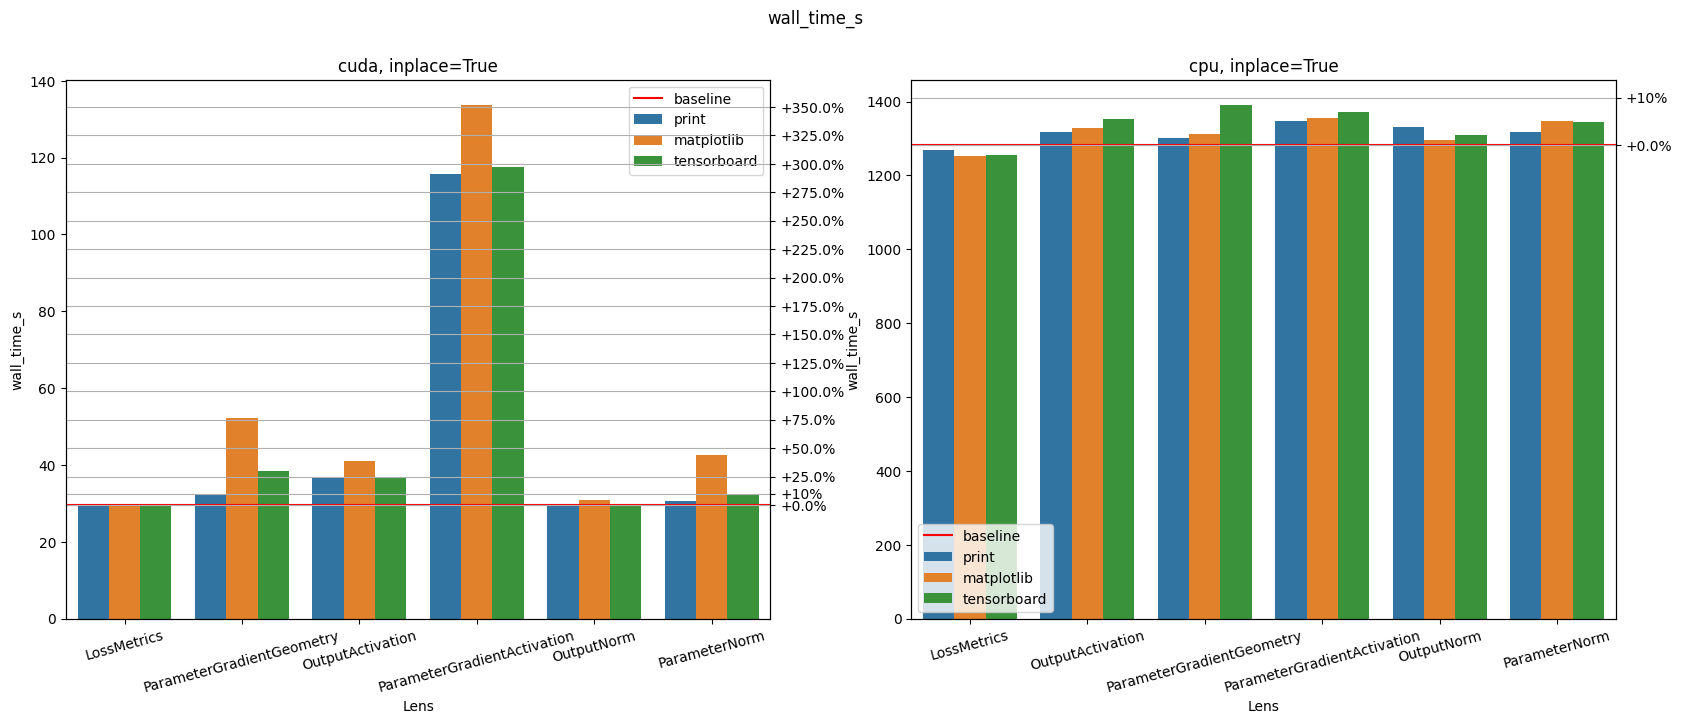

In [6]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'wall_time_s'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=True, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=True, ax=ax2)

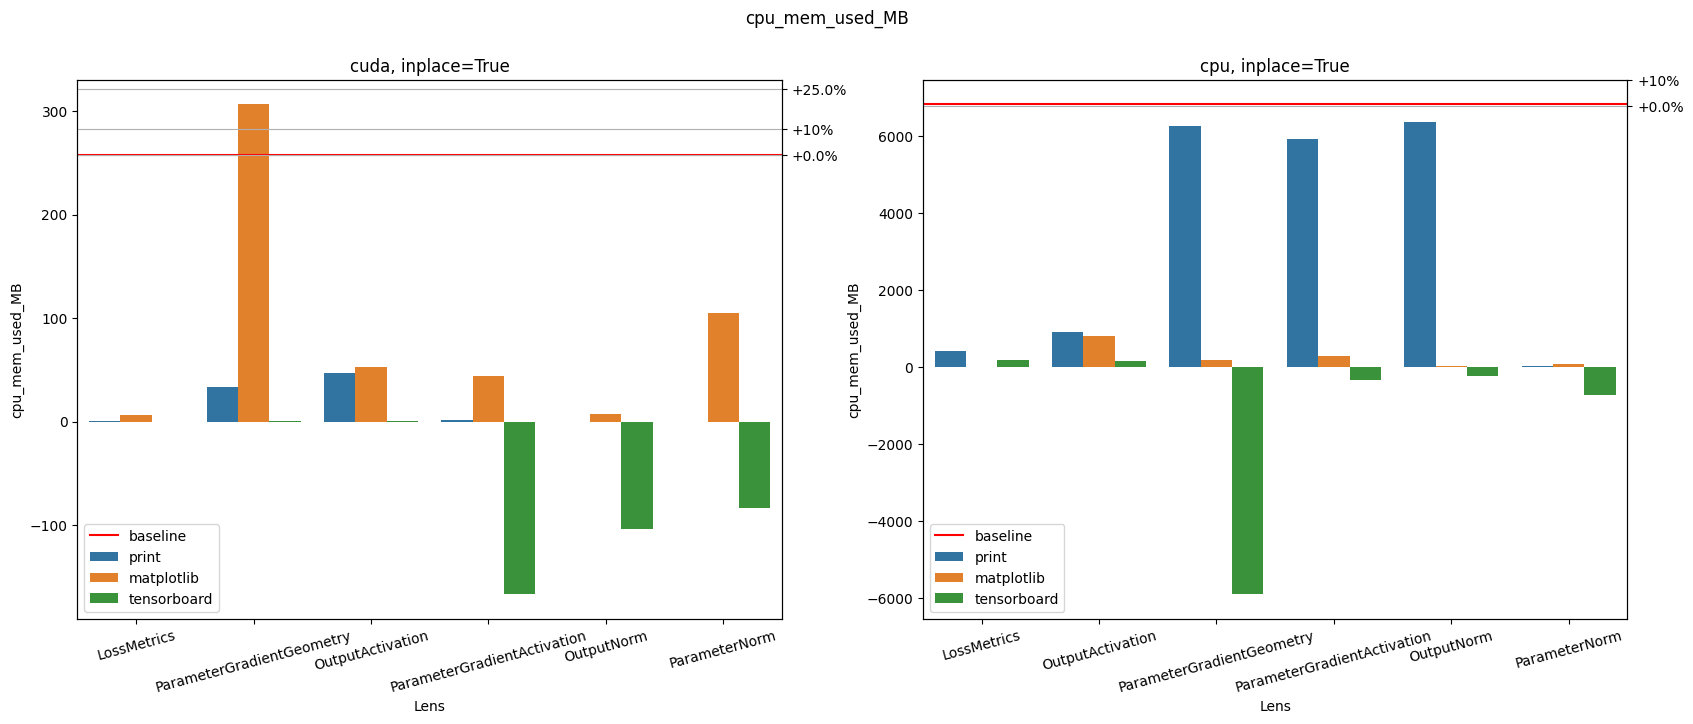

In [7]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'cpu_mem_used_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=True, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=True, ax=ax2)

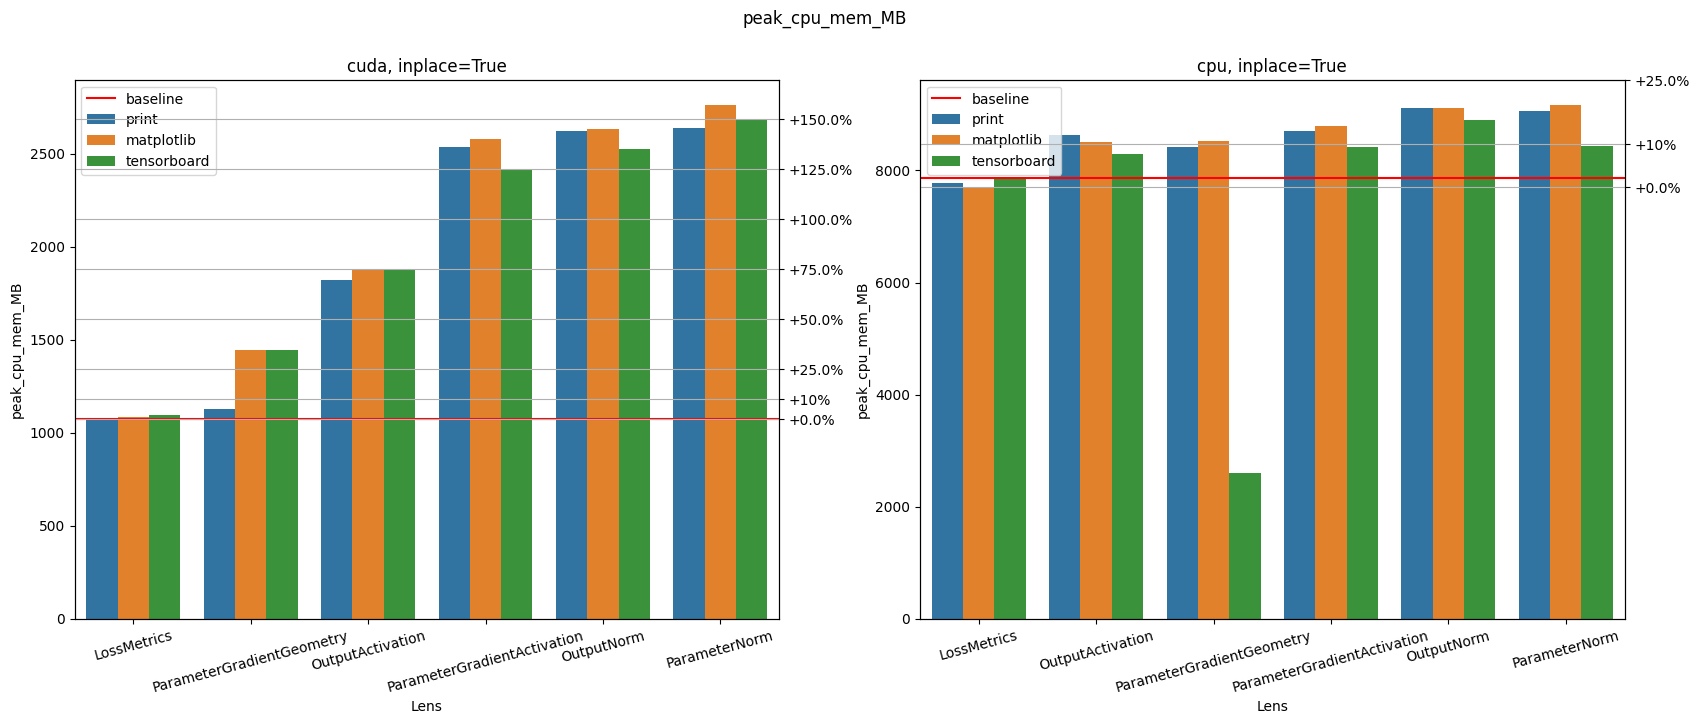

In [8]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'peak_cpu_mem_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=True, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=True, ax=ax2)

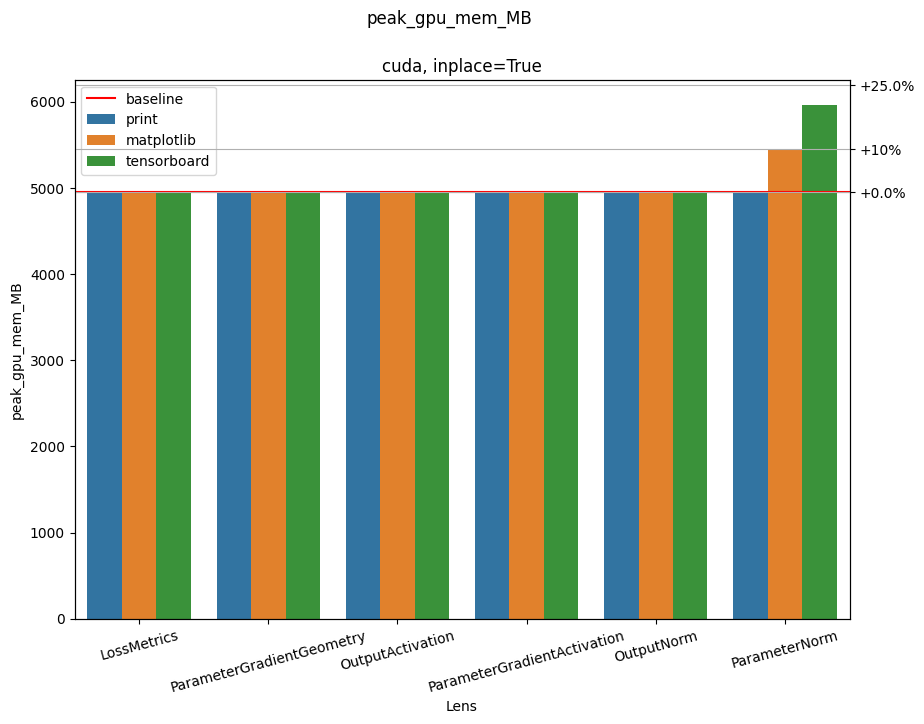

In [9]:
fig, ax1 = plt.subplots(figsize=(10, 7), ncols=1)
stat_name = 'peak_gpu_mem_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=True, ax=ax1)

# Benchmarking In-memory Implementation 

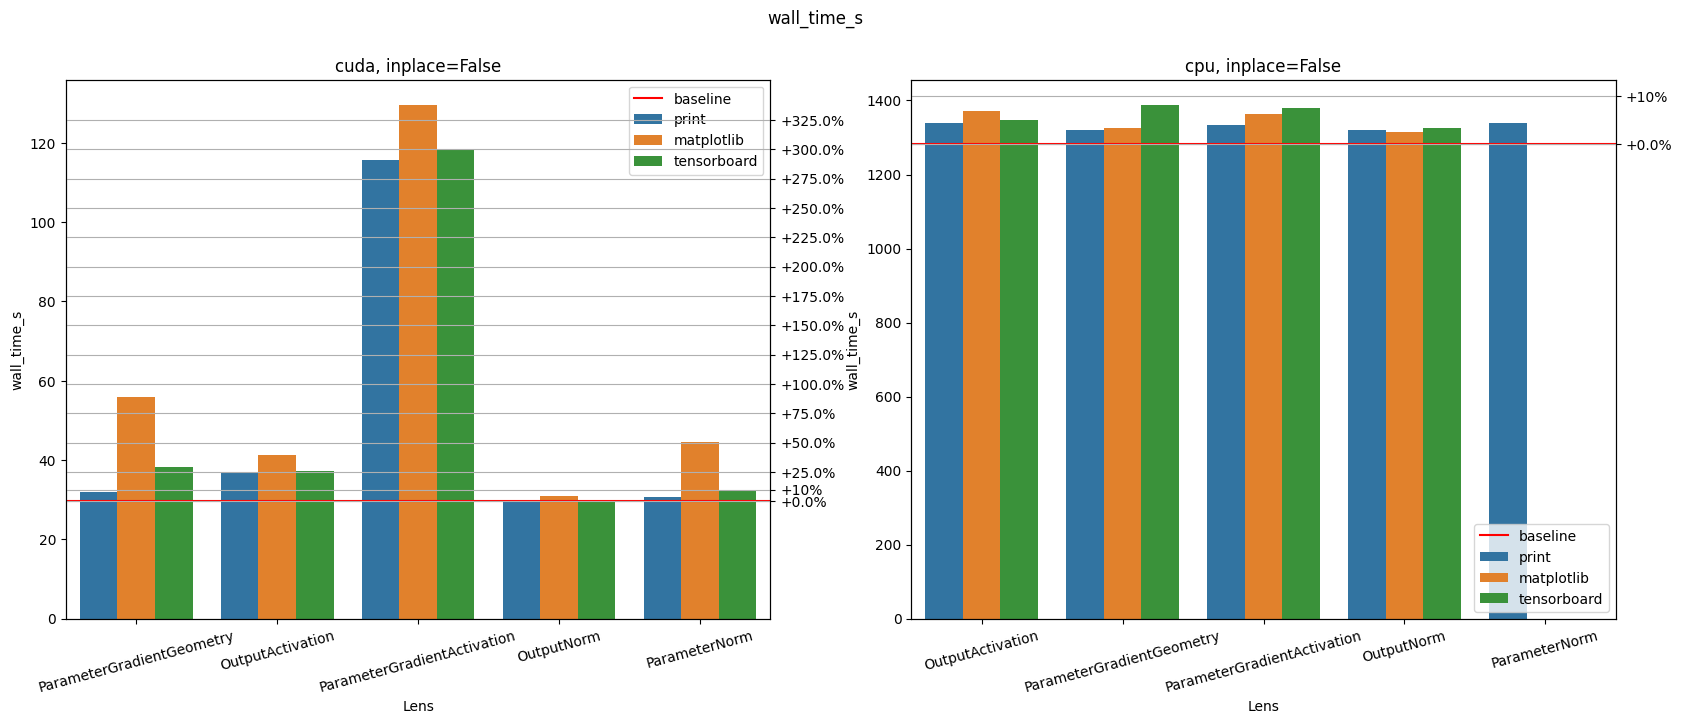

In [10]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'wall_time_s'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=False, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=False, ax=ax2)

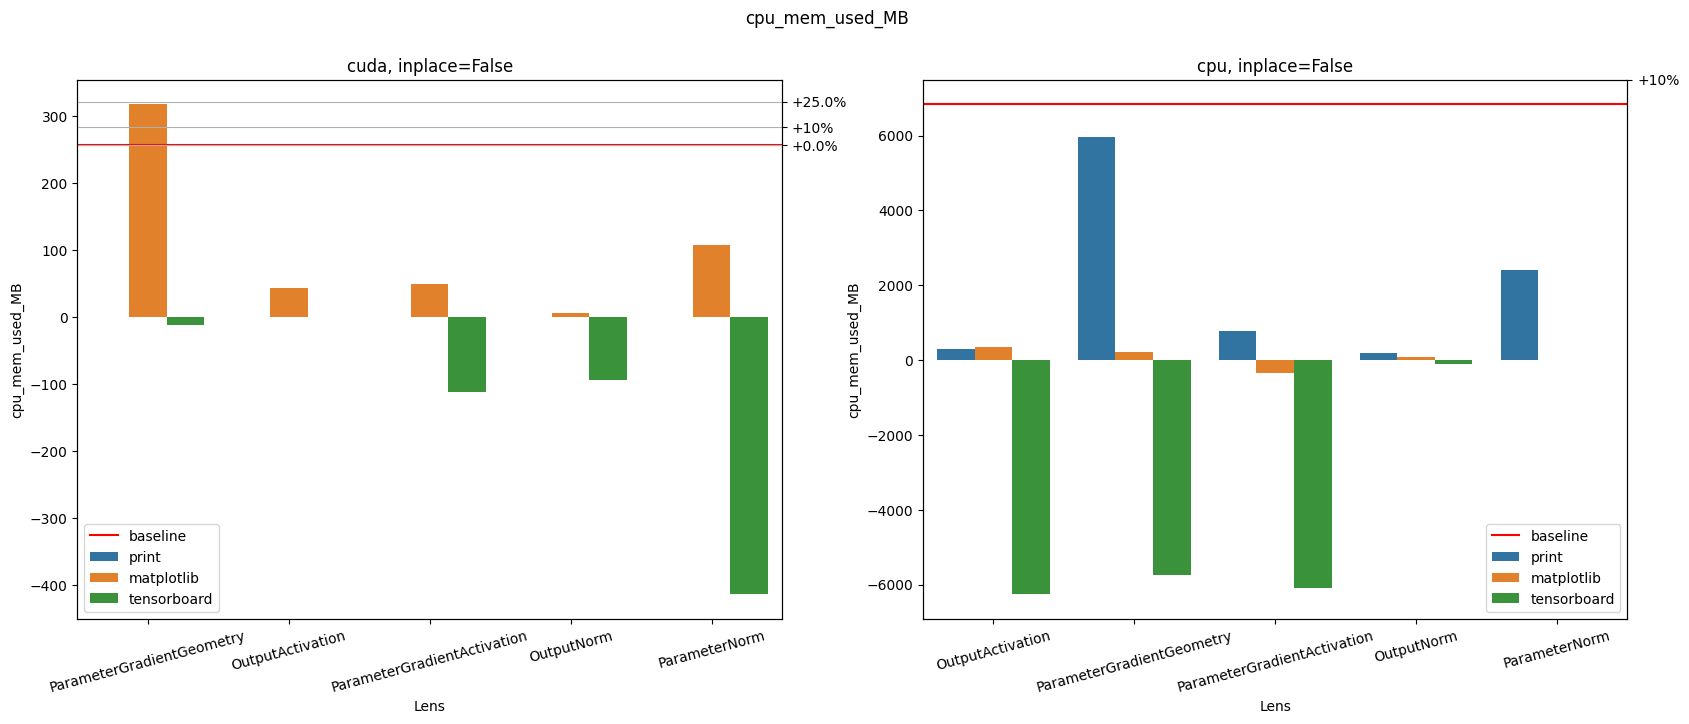

In [11]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'cpu_mem_used_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=False, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=False, ax=ax2)

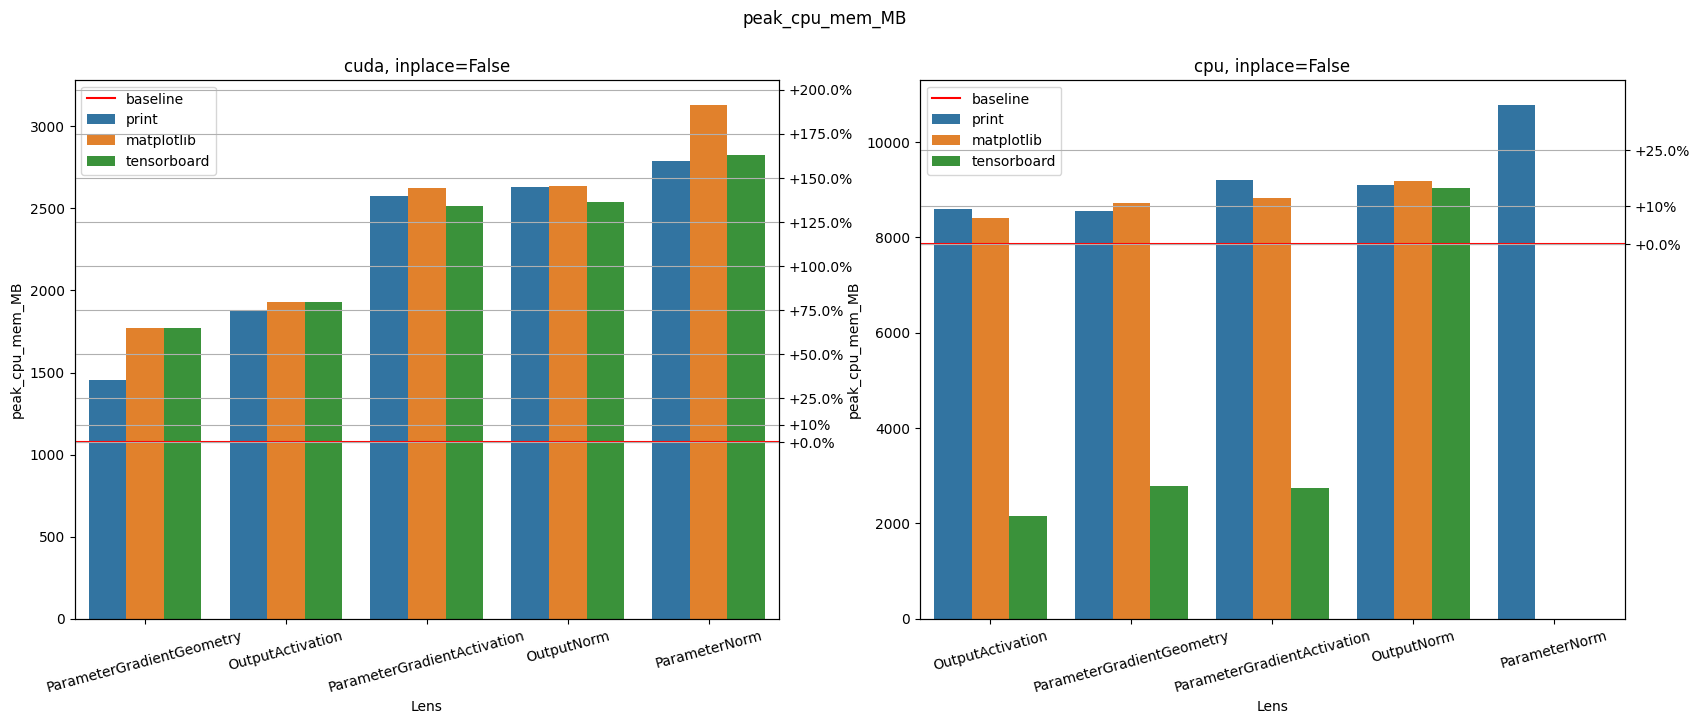

In [12]:
fig, [ax1, ax2] = plt.subplots(figsize=(20, 7), ncols=2)
stat_name = 'peak_cpu_mem_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=False, ax=ax1)
display_lens_bm(stat_name, df_cpu, inplace=False, ax=ax2)

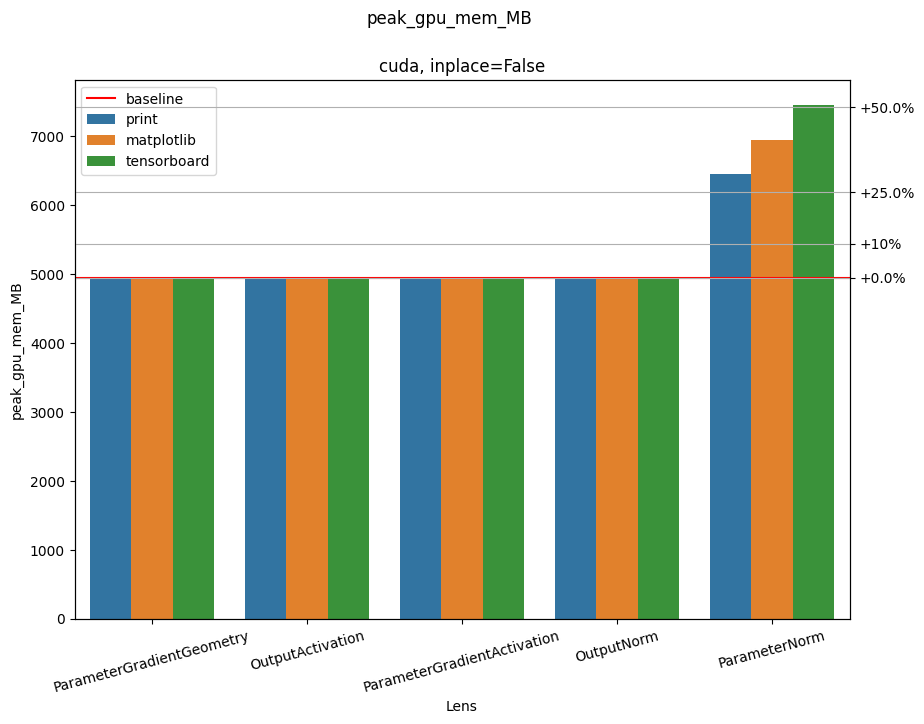

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 7), ncols=1)
stat_name = 'peak_gpu_mem_MB'
fig.suptitle(stat_name)
display_lens_bm(stat_name, df_gpu, inplace=False, ax=ax1)